In [1]:
import glob
import os
import json
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from tqdm import tqdm
from pathlib import Path
from red_gym_env_v2 import RedGymEnv

In [2]:
CHECKPOINTS = sorted(glob.glob("runs/poke_*_steps.zip"))
CHECKPOINTS = CHECKPOINTS[::50]
TEST_STATES = sorted(glob.glob("battle_states/Test/*.state"))

print("Found checkpoints:", len(CHECKPOINTS))
print("Found test states:", len(TEST_STATES))

Found checkpoints: 34
Found test states: 8


In [3]:
EPISODES_PER_STATE = 3
def eval_on_state(model, state_path):
    env_config = {
        "headless": True,
        "save_final_state": False,
        "early_stop": True,
        "action_freq": 60,
        "max_steps": 2000,
        "print_rewards": False,
        "save_video": False,
        "fast_video": False,
        "session_path": Path("battle_runs"),
        "gb_path": "/home/di-lab1/PokemonRedExperiments/PokemonRed.gb",
        "debug": False,
        "init_state": state_path
    }
    env = RedGymEnv(env_config)

    import glob as _glob
    original_glob = _glob.glob

    def force_one_state(path):
        # Intercept only the test state glob
        if "battle_states/Test" in path:
            return [state_path]    # ALWAYS return only the one we want
        return original_glob(path)

    wins = 0

    for _ in range(EPISODES_PER_STATE):
        # Apply the patch
        _glob.glob = force_one_state

        obs, info = env.reset()   # <-- this now loads ONLY our chosen test state

        # Remove the patch (important)
        _glob.glob = original_glob

        done = False
        info = {}

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

        if info.get("battle_won"):
            wins += 1

    env.close()
    return wins / EPISODES_PER_STATE


In [4]:
checkpoint_results = {}

for ckpt in tqdm(CHECKPOINTS):
    model = PPO.load(ckpt)
    state_winrates = []

    for state in TEST_STATES:
        wr = eval_on_state(model, state)
        state_winrates.append(wr)

    avg_wr = np.mean(state_winrates)
    checkpoint_results[ckpt] = avg_wr

100%|██████████| 34/34 [2:39:33<00:00, 281.58s/it]  


In [7]:
sorted_ckpts = sorted(checkpoint_results.items(), key=lambda x: x[1], reverse=True)

for ckpt, wr in sorted_ckpts:
    print(f"{ckpt}: {wr:.3f}")

runs/poke_100139008_steps.zip: 0.000
runs/poke_111935488_steps.zip: 0.000
runs/poke_123731968_steps.zip: 0.000
runs/poke_135528448_steps.zip: 0.000
runs/poke_147324928_steps.zip: 0.000
runs/poke_159121408_steps.zip: 0.000
runs/poke_170917888_steps.zip: 0.000
runs/poke_182976512_steps.zip: 0.000
runs/poke_194510848_steps.zip: 0.000
runs/poke_206569472_steps.zip: 0.000
runs/poke_218103808_steps.zip: 0.000
runs/poke_230162432_steps.zip: 0.000
runs/poke_241696768_steps.zip: 0.000
runs/poke_253755392_steps.zip: 0.000
runs/poke_265027584_steps.zip: 0.000
runs/poke_277086208_steps.zip: 0.000
runs/poke_288620544_steps.zip: 0.000
runs/poke_300679168_steps.zip: 0.000
runs/poke_312475648_steps.zip: 0.000
runs/poke_324272128_steps.zip: 0.000
runs/poke_336068608_steps.zip: 0.000
runs/poke_347865088_steps.zip: 0.000
runs/poke_359661568_steps.zip: 0.000
runs/poke_371458048_steps.zip: 0.000
runs/poke_383254528_steps.zip: 0.000
runs/poke_395051008_steps.zip: 0.000
runs/poke_406847488_steps.zip: 0.000
r

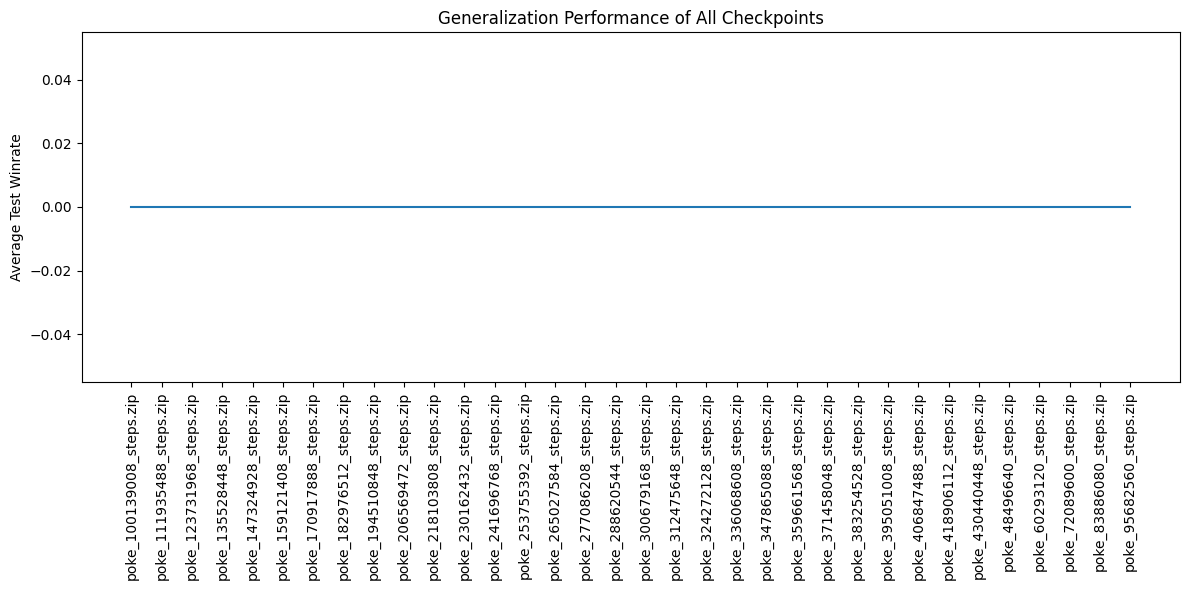

In [6]:
plt.figure(figsize=(12,6))
names = [os.path.basename(k) for k,_ in sorted_ckpts]
vals = [v for _,v in sorted_ckpts]

plt.plot(names, vals)
plt.xticks(rotation=90)
plt.ylabel("Average Test Winrate")
plt.title("Generalization Performance of All Checkpoints")
plt.tight_layout()
plt.show()